# 10 · Bayesian spectral analysis & visualization (capstone)

**SpectralBrain tutorial series — notebook 9 of 9.** (Previous: effect sizes, classification, harmonization.)

The finale. Frequentist tests gave us p-values and point estimates; the Bayesian
layer gives **full posterior distributions**: honest uncertainty, automatic
sparsity, a principled notion of "no meaningful effect," and normative deviation
scores. We close by tying geometry, statistics, and visualization into one
workflow.

### Learning objectives
1. Select predictive descriptors with **sparse horseshoe regression**.
2. Compare groups with **BEST** and judge effects against a **region of practical
   equivalence (ROPE)**.
3. Build a **Gaussian-process normative model** and read per-subject deviation
   z-scores.
4. Render a result back onto the anatomy, completing the pipeline.

> The feature/outcome cohort is **synthetic and clearly labelled**, with planted
> structure so the models have something to recover. MCMC uses short chains for
> speed; raise `draws`/`tune` for real analyses.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, matplotlib.pyplot as plt
import spectralbrain as sb
import spectralbrain.statistics as st
from _tutorial_utils import data_path

rng = np.random.default_rng(11)
n, p = 60, 8
X = rng.normal(size=(n, p))                       # p spectral-descriptor summaries per subject
true_beta = np.array([1.6, 0, 0, -1.1, 0, 0, 0, 0])
y = X @ true_beta + rng.normal(0, 0.5, n)         # an outcome driven by features 0 and 3
group = (rng.random(n) < 0.5).astype(int)         # 0 control, 1 patient
age = rng.uniform(20, 70, n)
print(f"synthetic cohort: {n} subjects, {p} descriptor features (SYNTHETIC — teaching only)")
print(f"outcome truly depends on features 0 and 3")

synthetic cohort: 60 subjects, 8 descriptor features (SYNTHETIC — teaching only)
outcome truly depends on features 0 and 3


## 1. Sparse horseshoe regression: which descriptors matter?

With many spectral descriptors, most are probably irrelevant to a given outcome.
The **horseshoe prior** encodes exactly that belief: it pulls most coefficients
hard toward zero while letting a few escape to their true value. Formally each
coefficient gets its own scale $\lambda_j$ drawn from a heavy-tailed half-Cauchy,
times a global shrinkage $\tau$:

$$\beta_j \sim \mathcal{N}(0,\, \tau^2 \lambda_j^2), \qquad \lambda_j \sim \mathrm{C}^+(0,1).$$

The posterior should light up features 0 and 3 and flatten the rest.

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1200,34,0.23,27
,1200,55,0.25,31


[06/09/26 02:30:37] INFO     Fitted with nutpie (600 draws × 2 chains).

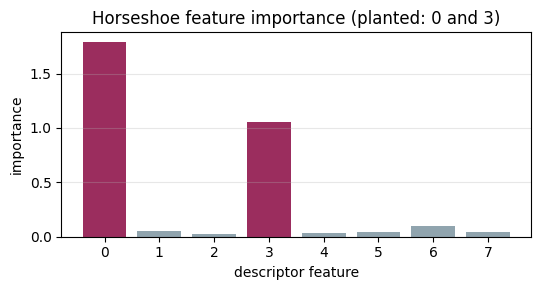

           mean     sd eti94_lb eti94_ub
beta[0]   1.789  0.058      1.7      1.9
beta[1]  -0.043   0.05    -0.15    0.029
beta[2]  -0.004  0.038   -0.088    0.065
beta[3]  -1.059  0.047     -1.1    -0.97
beta[4]   0.023  0.045   -0.049     0.12
beta[5]  -0.031  0.041    -0.12    0.037
beta[6]   0.096  0.055  -0.0024      0.2
beta[7]   0.038  0.043   -0.023     0.13


In [2]:
hs = st.HorseshoeRegression(tau_prior=0.1)
hs.fit(X, y, draws=600, tune=600, chains=2, sampler="auto")
imp = hs.feature_importance()
summ = hs.summary(var_names=["beta"])

fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.bar(range(p), imp, color=["#9b2d5e" if i in (0, 3) else "#90a4ae" for i in range(p)])
ax.set_xlabel("descriptor feature"); ax.set_ylabel("importance")
ax.set_title("Horseshoe feature importance (planted: 0 and 3)"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()
print(summ.iloc[:p, :4])

A forest plot of the coefficient posteriors makes the sparsity visible: the
relevant features have intervals clear of zero; the rest straddle it.

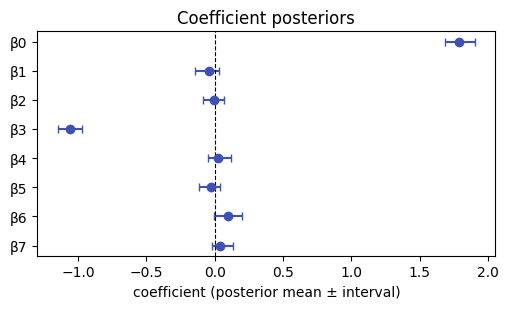

In [3]:
post = hs.trace_.posterior["beta"].values.reshape(-1, p)   # (samples, p) — version-proof
means = post.mean(0)
lo = np.percentile(post, 3, axis=0); hi = np.percentile(post, 97, axis=0)
fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.errorbar(means, range(p), xerr=[means - lo, hi - means], fmt="o", color="#3f51b5", capsize=3)
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_yticks(range(p)); ax.set_yticklabels([f"β{i}" for i in range(p)])
ax.set_xlabel("coefficient (posterior mean ± interval)"); ax.set_title("Coefficient posteriors")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 2. BEST: group comparison with a ROPE

A p-value cannot say "the groups are equivalent." The Bayesian estimation
(**BEST**) model returns the full posterior of the effect size, and we judge it
against a **region of practical equivalence (ROPE)**, a band around zero we deem
negligible. The posterior mass below / inside / above the ROPE answers "is there a
practically meaningful difference?" directly.

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1200,0,0.90,3
,1200,0,0.85,3


[06/09/26 02:30:45] INFO     Fitted with nutpie (600 draws × 2 chains).

posterior mean effect size (Cohen's d): -0.76
ROPE decision: P(below)=0.989  P(in ROPE)=0.010  P(above)=0.001


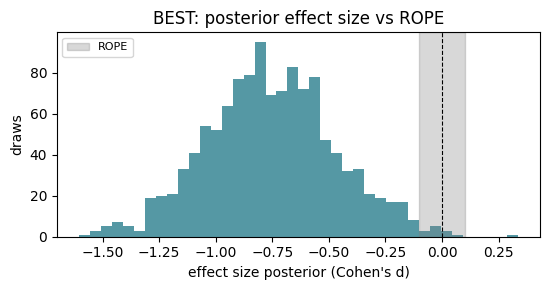

In [4]:
desc_controls = X[group == 0, 0] + rng.normal(0, 0.3, (group == 0).sum())
desc_patients = X[group == 1, 0] + 0.8 + rng.normal(0, 0.3, (group == 1).sum())

best = st.BayesianGroupComparison(rope=(-0.1, 0.1))
best.fit(desc_controls, desc_patients, draws=600, tune=600, chains=2)
es = best.effect_size_posterior()
rope = best.rope_probability()
print(f"posterior mean effect size (Cohen's d): {es.mean():.2f}")
print(f"ROPE decision: P(below)={rope['p_below']:.3f}  "
      f"P(in ROPE)={rope['p_rope']:.3f}  P(above)={rope['p_above']:.3f}")

fig, ax = plt.subplots(figsize=(5.6, 3.0))
ax.hist(es, bins=40, color="#2a7f8e", alpha=0.8)
ax.axvspan(-0.1, 0.1, color="grey", alpha=0.3, label="ROPE")
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("effect size posterior (Cohen's d)"); ax.set_ylabel("draws")
ax.set_title("BEST: posterior effect size vs ROPE"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Gaussian-process normative modelling

A **normative model** learns the healthy relationship between a covariate (say
age) and a measurement, with uncertainty, then scores each new subject by how far
they deviate. SpectralBrain fits this with a Gaussian process. We train on
controls, draw the normative mean and its $\pm 2\sigma$ band over a fresh age
grid, and convert each patient's value into a deviation **z-score**:

$$z(x) = \frac{y_{\text{obs}} - \mu_{\text{norm}}(x)}{\sigma_{\text{norm}}(x)}.$$

> Evaluate the GP on a *grid distinct from the training ages*; predicting exactly
> at training points can make the conditional covariance singular.

/usr/local/lib/python3.12/dist-packages/pytensor/assumptions/diagonal.py:53: RuntimeWarning: invalid value encountered in multiply
  result = FactState.FALSE if np.any(data * ~eye_mask) else FactState.TRUE


Progress,Draws,Divergences,Step Size,Gradients/Draw
,800,0,0.95,3
,800,0,1.00,3


[06/09/26 02:31:01] INFO     Fitted with nutpie (400 draws × 2 chains).

/usr/local/lib/python3.12/dist-packages/pytensor/assumptions/diagonal.py:53: RuntimeWarning: invalid value encountered in multiply
  result = FactState.FALSE if np.any(data * ~eye_mask) else FactState.TRUE
Sampling: [f_pred_a1951579]


Output()

...

Output()

/usr/local/lib/python3.12/dist-packages/pytensor/assumptions/diagonal.py:53: RuntimeWarning: invalid value encountered in multiply
  result = FactState.FALSE if np.any(data * ~eye_mask) else FactState.TRUE
Sampling: [f_pred_a2485edf]


Output()

/usr/local/lib/python3.12/dist-packages/pytensor/assumptions/diagonal.py:53: RuntimeWarning: invalid value encountered in multiply
  result = FactState.FALSE if np.any(data * ~eye_mask) else FactState.TRUE
Sampling: [f_pred_e7d05d4d]


Output()

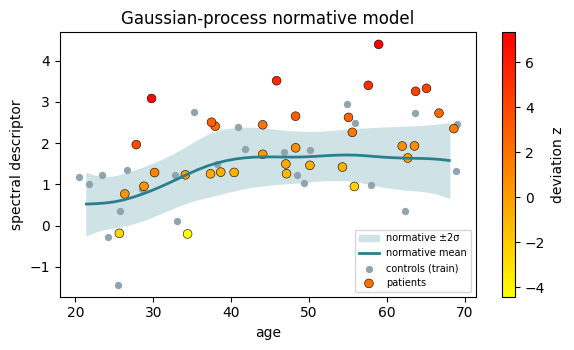

patient deviation z-scores: mean=1.39, 13 of 34 beyond z=+2


In [5]:
ctrl = group == 0
age_c, y_c = age[ctrl], X[ctrl, 0] + 0.03 * age[ctrl]      # mild age trend in controls
gp = st.GaussianProcessNormative(kernel="matern52")
gp.fit(age_c.reshape(-1, 1), y_c, draws=400, tune=400, chains=2, sampler="auto")

grid = np.linspace(age.min() + 1, age.max() - 1, 40).reshape(-1, 1)
mu, sd = gp.predict(grid)

age_p = age[~ctrl]; y_p = X[~ctrl, 0] + 0.03 * age_p + rng.normal(0.6, 0.4, (~ctrl).sum())
z = np.array([gp.deviation(float(a), float(v)) for a, v in zip(age_p, y_p)])

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.fill_between(grid.ravel(), mu - 2 * sd, mu + 2 * sd, color="#cfe3e7", label="normative ±2σ")
ax.plot(grid.ravel(), mu, color="#2a7f8e", lw=2, label="normative mean")
ax.scatter(age_c, y_c, s=18, color="#90a4ae", label="controls (train)")
sc = ax.scatter(age_p, y_p, c=z, cmap="autumn_r", s=40, edgecolor="k", lw=0.4, label="patients")
ax.set_xlabel("age"); ax.set_ylabel("spectral descriptor")
ax.set_title("Gaussian-process normative model"); ax.legend(fontsize=7)
plt.colorbar(sc, label="deviation z"); plt.tight_layout(); plt.show()
print(f"patient deviation z-scores: mean={z.mean():.2f}, "
      f"{(z > 2).sum()} of {len(z)} beyond z=+2")

## 4. Capstone: back to the anatomy

Every number above ultimately describes a brain structure. We close the loop by
computing a per-vertex effect on the **real** left hippocampus and rendering it
with the six-view tool, the same figure you would publish for a hippocampal
sclerosis finding. (The two-group field is synthetic, planted in the head, as in
notebook 7.)

[06/09/26 02:34:19] INFO     Laplacian (cotangent): N=8192, nnz=56578

2026-06-09 02:34:23.682 (   1.059s) [    7F8BD522C080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


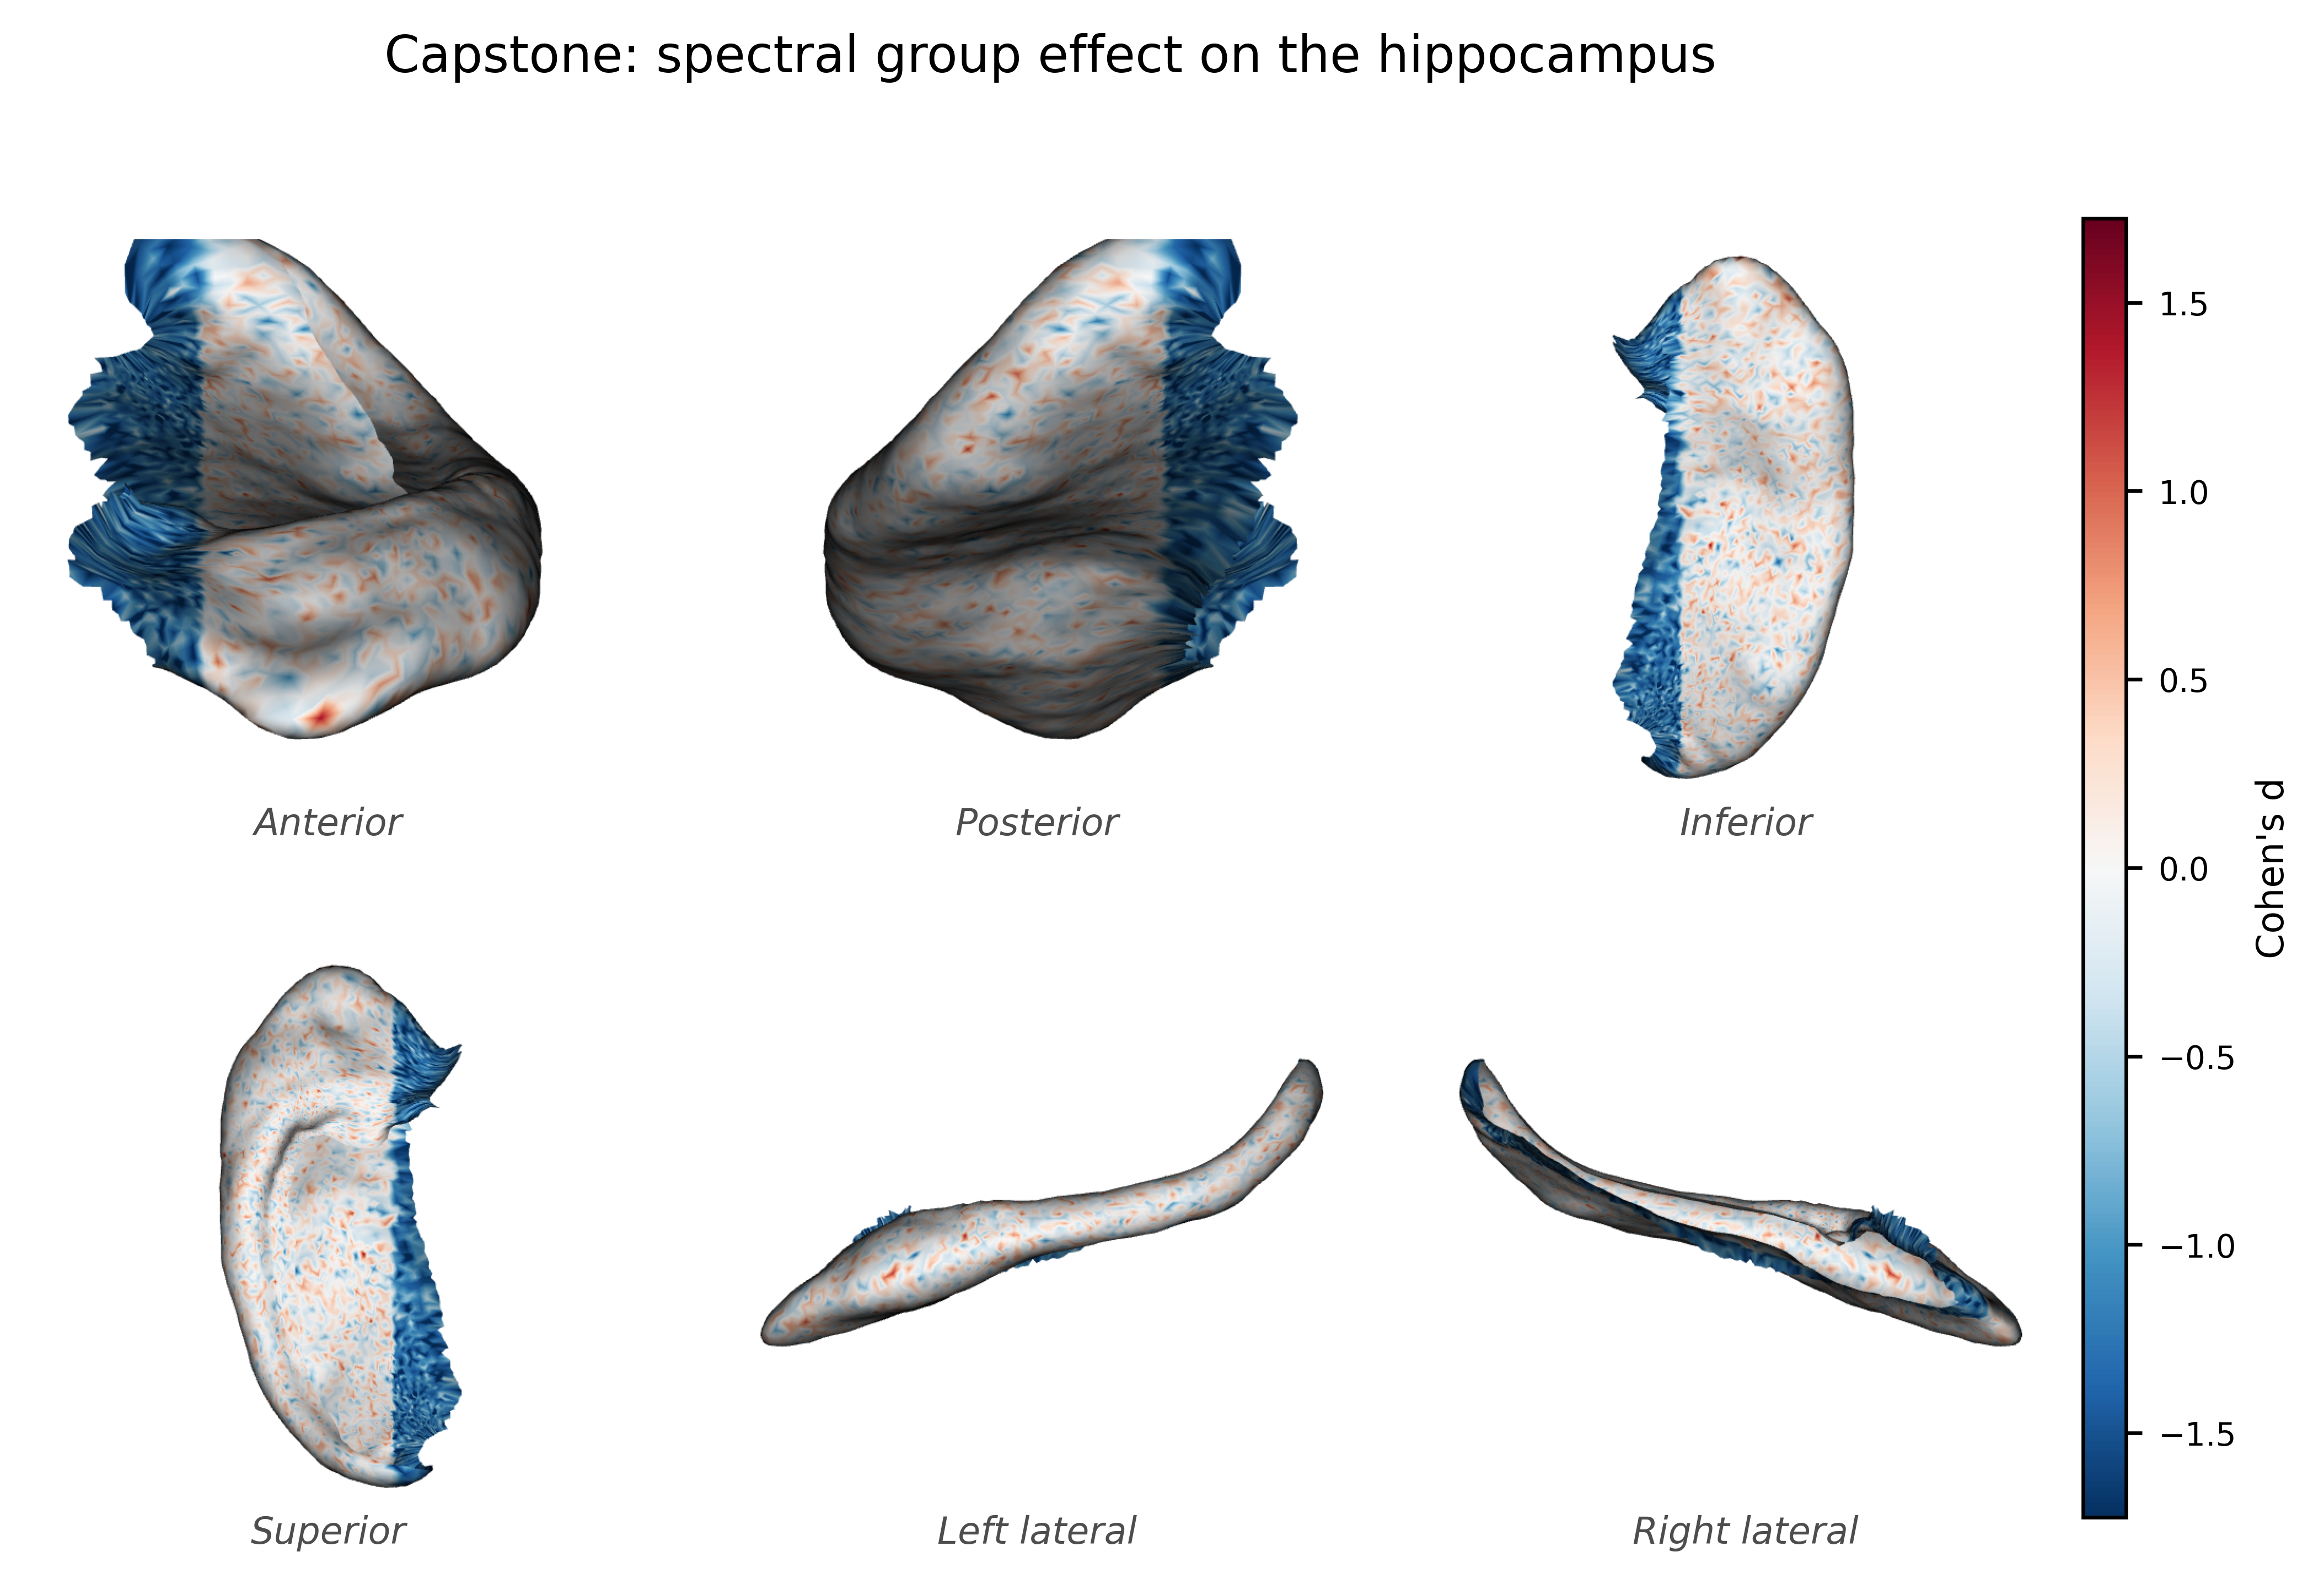

In [6]:
from spectralbrain.viz import plot_surface_sixview
mesh = sb.BrainMesh(*sb.load_gifti_surface(
    data_path("hippunfold", "sub03", "hemi-L_space-T1w_den-8k_label-hipp_midthickness.surf.gii")))
dec = mesh.decompose(k=200)
field = np.asarray(sb.compute_hks(dec, n_times=100))[:, 60]
field = (field - field.mean()) / field.std()
head = mesh.vertices[:, 0] > np.percentile(mesh.vertices[:, 0], 80)

A = field[None, :] + rng.normal(0, 1, (16, mesh.n_vertices))
B = field[None, :] + rng.normal(0, 1, (16, mesh.n_vertices)); B[:, head] += 1.2
d_map = np.asarray(st.cohens_d_map(A, B))

fig = plot_surface_sixview(mesh, scalars=d_map, cmap="RdBu_r", signed=True,
                           scalar_bar_title="Cohen's d",
                           title="Capstone: spectral group effect on the hippocampus")
plt.show()

## The whole pipeline, in one breath

You have now traversed the entire library:

1. **LBO** → the spectrum of a surface (notebook 1)
2. **I/O** → any neuroimaging format becomes a mesh (2)
3. **ShapeDNA** → a global, pose-free fingerprint (3)
4. **HKS / SI-HKS** → local, multi-scale, scale-invariant descriptors (4)
5. **WKS / GPS** → band-pass descriptors and an embedding (5)
6. **Functional maps & distances** → relating shapes (6)
7. **Cohorts & vertex-wise stats** → where shapes differ, with FWE/FDR/TFCE (7)
8. **Effect sizes & harmonisation** → how much, how reliably, across sites (8)
9. **Bayesian & visualization** → uncertainty, sparsity, normative scores, figures (9)

From a triangle mesh to a posterior-backed, publication-ready anatomical map.


## Exercises

1. **Sparsity vs signal.** Add a third true predictor with a small coefficient
   (e.g. 0.3) and refit the horseshoe. Does it survive shrinkage? Tune `tau_prior`.
2. **ROPE width.** Re-run BEST with `rope=(-0.3, 0.3)`. How does the practical
   decision change for the same data?
3. **Kernel choice.** Refit the normative model with `kernel='rbf'` and
   `'matern32'`. How does the uncertainty band change, especially at the age
   extremes?
4. **Real outcome.** Replace the synthetic outcome with a real per-subject summary
   (e.g. each subject's mean HKS over vertices) from the four hippocampi and run
   the horseshoe on whatever covariate you have.
5. **Posterior plots.** Explore `spectralbrain.viz.bayes` (`plot_forest`,
   `plot_posterior`) and reproduce the figures in sections 1–2 with the library's
   own plotting helpers.


## Where to go from here

This series used five subjects to keep everything runnable; the same code scales
to full cohorts by swapping the loaders in notebook 2 for `discover_bids` /
`discover_freesurfer` and letting `load_group` stream subjects in parallel. The
methods transfer unchanged from the hippocampus to thalamic nuclei, cortical
surfaces, and white-matter tracts.

If you use SpectralBrain in your work, please cite the software (see the
repository `CITATION.cff`). Bug reports and contributions are welcome. Thank you
for working through the series.
